# Multimodel Example

This notebook shows a concrete `multi_transit` setup where two atmospheric regions are described in separate TauREx parameter files and combined into a single weighted transmission spectrum. The example mirrors a day-night style configuration: a hotter, wetter region and a cooler, drier region.

## Data Note

The example below uses the opacity files prepared in the setup notebook together with checked-in parameter files under `examples/parfiles`. To keep the example runnable in a lightweight local setup, the regional models use absorption-only contributions.

The notebook changes into the project root before loading the main file so that the repo-relative paths inside the `.par` files resolve consistently.

In [1]:
from pathlib import Path
import os
import sys

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / '_shared.py').exists():
        sys.path.insert(0, str(candidate))
        break
    nested = candidate / 'examples' / 'notebooks'
    if (nested / '_shared.py').exists():
        sys.path.insert(0, str(nested))
        break

from _shared import PROJECT_ROOT, ensure_opacity_data

ensure_opacity_data(download=False)
os.chdir(PROJECT_ROOT)

project_root = Path.cwd()
parfile_dir = project_root / 'examples' / 'parfiles'
day_path = parfile_dir / 'multimodel_day.par'
night_path = parfile_dir / 'multimodel_night.par'
main_path = parfile_dir / 'multimodel_main.par'

print(f'Project root: {project_root.name}')
print(f'Day-side file: {day_path.relative_to(project_root)}')
print(f'Night-side file: {night_path.relative_to(project_root)}')
print(f'Main multimodel file: {main_path.relative_to(project_root)}')

Project root: taurex3
Day-side file: examples/parfiles/multimodel_day.par
Night-side file: examples/parfiles/multimodel_night.par
Main multimodel file: examples/parfiles/multimodel_main.par


## How the parameter files are split

This example uses three checked-in `.par` files.

- `examples/parfiles/multimodel_main.par` is the entry point. It defines the shared global paths, star, planet, a default atmosphere block, and the `multi_transit` model itself.
- `examples/parfiles/multimodel_day.par` defines the hotter, wetter region.
- `examples/parfiles/multimodel_night.par` defines the cooler, drier region.

Only the main file is printed below, because that is the file a user would normally start from. The regional files are linked through the `parfiles` entry inside that main file. More background on TauREx input files is in `08_parameter_files.ipynb` and in the input-file docs at `docs/user/taurex/inputfile.rst`.

In [2]:
print(f'Main parameter file: {main_path.relative_to(project_root)}\n')
print(main_path.read_text())

print('\nCompanion regional files:')
print(f'  - {day_path.relative_to(project_root)}')
print(f'  - {night_path.relative_to(project_root)}')

Main parameter file: examples/parfiles/multimodel_main.par

[Global]
xsec_path = examples/tmp/xsec
cia_path = examples/tmp/cia

[Chemistry]
chemistry_type = taurex
fill_gases = H2,He
ratio = 0.1756

    [[H2O]]
    gas_type = constant
    mix_ratio = 1e-3

[Temperature]
profile_type = isothermal
T = 1800

[Pressure]
profile_type = Simple
atm_min_pressure = 1e-5
atm_max_pressure = 1e5
nlayers = 80

[Planet]
planet_type = Simple
planet_mass = 0.74
planet_radius = 1.38

[Star]
star_type = blackbody
temperature = 6117
radius = 1.16

[Model]
model_type = multi_transit
parfiles = examples/parfiles/multimodel_day.par,examples/parfiles/multimodel_night.par
fractions = 0.65,0.35

Companion regional files:
  - examples/parfiles/multimodel_day.par
  - examples/parfiles/multimodel_night.par


## What TauREx is doing here

`multimodel_main.par` is the only file passed directly to `ParameterParser`. TauREx reads that main file first, sees `model_type = multi_transit`, and then follows the `parfiles` entry to load the day-side and night-side region files.

The main file supplies the shared context for the run: global data paths, star, planet, and a default atmospheric setup. The regional files then override the parts that differ between regions, here mainly the temperature and water abundance. The `fractions` entry in the main file sets how strongly each regional spectrum contributes to the final combined spectrum.

In [5]:
from taurex.parameter import ParameterParser

parser = ParameterParser()
parser.read(str(main_path))
parser.setup_globals()
model = parser.generate_appropriate_model()
model.build()

internal_model = model._multimodel

print('Top-level model:', type(model).__name__)
print('Internal multimodel:', type(internal_model).__name__)
print('Number of regions:', len(internal_model._sub_models))
print('Fractions:', internal_model._fractions)
print('First fitting parameters:', list(model.fittingParameters)[:8])

Top-level model: MultiParameterTransitModel
Internal multimodel: MultiTransitModel
Number of regions: 2
Fractions: [0.65, 0.35]
First fitting parameters: ['fr_1', 'fr_2', 'planet_mass', 'planet_radius', 'planet_distance', 'planet_sma', 'distance', 'm1_T']


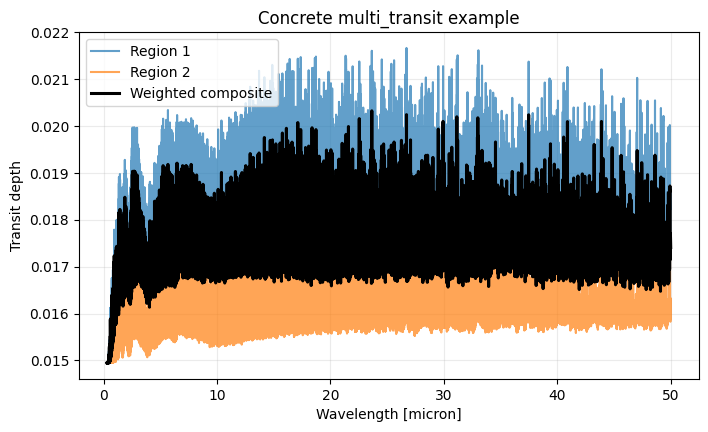

In [4]:
import matplotlib.pyplot as plt

combined_grid, combined_flux, _, _ = model.model()
combined_wavelength = 10000 / combined_grid

fig, ax = plt.subplots(figsize=(8, 4.5))
for index, sub_model in enumerate(internal_model._sub_models, start=1):
    region_grid, region_flux, _, _ = sub_model.model(wngrid=combined_grid, cutoff_grid=False)
    ax.plot(10000 / region_grid, region_flux, label=f'Region {index}', alpha=0.7)

ax.plot(combined_wavelength, combined_flux, color='black', linewidth=2.2, label='Weighted composite')
ax.set_xlabel('Wavelength [micron]')
ax.set_ylabel('Transit depth')
ax.set_title('Concrete multi_transit example')
ax.legend()
ax.grid(alpha=0.25)
plt.show()